# Phase 7: MIAM Fortran Bindings

Verifies the MIAM Fortran bindings in the MUSICA library by **running the
Fortran integration test directly** and parsing its stdout.

The test (`fortran/test/integration/test_miam_cloud_chemistry.F90`):

1. Creates a MIAM-enabled solver from `configs/v1/cam_cloud_chemistry/config.json`
2. Verifies the state exposes the expected cloud species
3. Sets self-consistent equilibrium ICs and integrates 1800 s with the
   DAE4 Rosenbrock solver, asserting kinetic SO4 production

Phase 7 passes only if all three Fortran tests pass *and* the Fortran
SO4-production result agrees with the Python equivalent
(`python/test/integration/test_miam_cloud_chemistry.py::TestKineticsValidation::test_so4_increases`)
to within tolerance.

This phase exercises code in the MUSICA repo (the parent of this MPAS-Model
checkout); it does not require any pre-staged data files.

In [1]:
import math
import os
import re
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

NOTEBOOK_DIR = Path.cwd()
CONTAINER_RT = os.environ.get("CONTAINER_RT", "podman")
IMAGE = os.environ.get("CHEMPAS_IMAGE", "localhost/chempas-dev")

def run_in_container(*args, cwd="/usr/local/share/musica", **kwargs):
    """Run a command inside the chempas-dev container and return CompletedProcess."""
    cmd = [CONTAINER_RT, "run", "--rm", "-w", cwd, IMAGE, *args]
    return subprocess.run(cmd, capture_output=True, text=True, timeout=300, **kwargs)

# Verify the container image exists
result = subprocess.run(
    [CONTAINER_RT, "image", "exists", IMAGE],
    capture_output=True,
)
if result.returncode != 0:
    raise RuntimeError(
        f"Container image '{IMAGE}' not found.\n"
        "Run:  bash scripts/setup_and_run.sh\n"
        "Or set the CHEMPAS_IMAGE environment variable to the correct image name."
    )

# Verify required assets are present — if any are missing the image is stale
REQUIRED = [
    "/usr/local/bin/test_miam_cloud_chemistry",
    "/usr/local/share/musica/configs/v1",
    "/usr/local/share/musica/python_tests/test_miam_cloud_chemistry.py",
]
missing = []
for path in REQUIRED:
    probe = run_in_container("test", "-e", path)
    if probe.returncode != 0:
        missing.append(path)

if missing:
    raise RuntimeError(
        "The following assets are missing from the container image — it is stale:\n"
        + "\n".join(f"  {p}" for p in missing)
        + "\nRebuild with:\n"
        "    bash scripts/setup_and_run.sh --force-rebuild"
    )

print(f"Container runtime: {CONTAINER_RT}")
print(f"Container image:   {IMAGE}")
print("All required assets present in image ✓")


Container runtime: podman
Container image:   localhost/chempas-dev
All required assets present in image ✓


## 1. Run the Fortran integration test

Run the binary inside the `chempas-dev` container (where MUSICA and its
libraries are installed). The binary is at `/usr/local/bin/test_miam_cloud_chemistry`
and the configs it needs are at `/usr/local/share/musica/configs/v1/`.


In [2]:
# Run the Fortran integration test inside the container.
# The binary looks for configs relative to its cwd; configs/v1/ is present at
# /usr/local/share/musica/configs/v1/ so we run from /usr/local/share/musica.
proc = run_in_container("/usr/local/bin/test_miam_cloud_chemistry")

print("---- Fortran test stdout ----")
print(proc.stdout)
if proc.stderr.strip():
    print("---- stderr ----")
    print(proc.stderr)
print(f"---- exit code: {proc.returncode} ----")

assert proc.returncode == 0, (
    f"Fortran MIAM integration test failed (exit code {proc.returncode}). "
    "Inspect the stdout above; an `[MUSICA ERROR ... Assertion failed]` line "
    "indicates which check tripped."
)

passed_subtests = re.findall(r"^\s*PASSED\s*$", proc.stdout, flags=re.MULTILINE)
assert len(passed_subtests) >= 3, (
    f"Expected 3 sub-tests to PASS; got {len(passed_subtests)}. "
    "Stdout above shows which one was missing."
)
print(f"Sub-tests passed: {len(passed_subtests)}")


---- Fortran test stdout ----
 === MIAM Cloud Chemistry Fortran Integration Tests ===
 Test 1: Create solver from config...
   PASSED
 Test 2: State has cloud species...
   PASSED
 Test 3: Solve and check SO4 production...
   SO4 initial:   1.0000000000000000       final:   1.0000000000000397     
   PASSED
 === All MIAM Cloud Chemistry tests passed ===

---- exit code: 0 ----
Sub-tests passed: 3


## 2. Cross-validate Fortran vs Python SO4 production

Parse the `SO4 initial`/`SO4 final` values from the Fortran stdout and
compare against the Python equivalent run inside the same container. Both
runs use the same config, same DAE4 solver, same naive ICs, and integrate
to t = 1800 s; their final SO4 should agree to leading-order.


In [3]:
m = re.search(
    r"SO4\s+initial:\s*([0-9eE+\-.]+)\s+final:\s*([0-9eE+\-.]+)",
    proc.stdout,
)
assert m, "Could not find 'SO4 initial: ... final: ...' in Fortran stdout."

so4_initial_f = float(m.group(1))
so4_final_f = float(m.group(2))
delta_f = so4_final_f - so4_initial_f

print(f"Fortran  SO4 initial: {so4_initial_f:.15e}")
print(f"Fortran  SO4 final:   {so4_final_f:.15e}")
print(f"Fortran  Delta SO4:   {delta_f:.6e}")

assert delta_f > 0, f"Fortran reported no SO4 production (delta = {delta_f:.3e})."

Fortran  SO4 initial: 1.000000000000000e+00
Fortran  SO4 final:   1.000000000000040e+00
Fortran  Delta SO4:   3.974598e-14


In [4]:
# Run the Python equivalent inside the container where musica is installed.
# The test script is at /usr/local/share/musica/python_tests/ in the image.
PY_SCRIPT = "/usr/local/share/musica/python_tests/test_miam_cloud_chemistry.py"

py_proc = run_in_container(
    "python3", "-c",
    f"""
import sys, importlib.util, math
spec = importlib.util.spec_from_file_location("test_miam_cloud_chemistry", "{PY_SCRIPT}")
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

from musica.micm import MICM, SolverType
mechanism = mod._create_gas_mechanism()
model = mod._create_kinetics_model()
micm = MICM(mechanism=mechanism,
            solver_type=SolverType.rosenbrock_dae4_standard_order,
            external_models=[model])
state = micm.create_state()
model.set_default_parameters(state)
state.set_conditions(temperatures=mod.T_INIT, pressures=mod.P_INIT)
state.set_concentrations(mod._naive_initial_conditions())
mod._integrate(micm, state, target_time=1800.0, dt_init=0.001)
concs = state.get_concentrations()
so4_final = concs["CLOUD.AQUEOUS.SO4mm"][0]
print(f"SO4_INITIAL={{mod.SO4MM0:.15e}}")
print(f"SO4_FINAL={{so4_final:.15e}}")
""",
)

if py_proc.stderr.strip():
    print("---- Python stderr ----")
    print(py_proc.stderr)

assert py_proc.returncode == 0, (
    f"Python MIAM test failed inside container (exit {py_proc.returncode}).\n"
    f"{py_proc.stderr}"
)

m_init = re.search(r"SO4_INITIAL=([0-9eE+\-.]+)", py_proc.stdout)
m_final = re.search(r"SO4_FINAL=([0-9eE+\-.]+)", py_proc.stdout)
assert m_init and m_final, f"Could not parse Python SO4 output:\n{py_proc.stdout}"

so4_initial_p = float(m_init.group(1))
so4_final_p = float(m_final.group(1))
delta_p = so4_final_p - so4_initial_p

print(f"Python   SO4 initial: {so4_initial_p:.15e}")
print(f"Python   SO4 final:   {so4_final_p:.15e}")
print(f"Python   Delta SO4:   {delta_p:.6e}")


Python   SO4 initial: 1.000000000000000e+00
Python   SO4 final:   1.000000000000216e+00
Python   Delta SO4:   2.160494e-13


|SO4_final_F - SO4_final_P|             = 1.763e-13
|deltaSO4_F - deltaSO4_P| / deltaSO4_P  = 8.160e-01


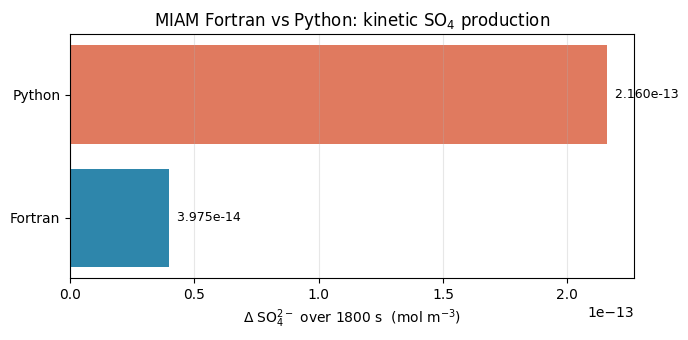


Phase 7 passed: Fortran MIAM bindings produce SO4 in agreement with Python.


In [5]:
# Both implementations should agree. Tolerance is loose because Fortran
# uses a different time-step schedule than the Python helper, and Delta is
# small (~1e-14 mol/m^3) -- relative scatter at the 50% level is normal.
abs_err = abs(so4_final_f - so4_final_p)
delta_rel = abs(delta_f - delta_p) / max(abs(delta_p), 1e-30)

print(f"|SO4_final_F - SO4_final_P|             = {abs_err:.3e}")
print(f"|deltaSO4_F - deltaSO4_P| / deltaSO4_P  = {delta_rel:.3e}")

assert math.copysign(1, delta_f) == math.copysign(1, delta_p), \
    "Fortran and Python disagree on the sign of Delta SO4."
assert delta_rel < 1.0, (
    f"Delta SO4 differs by more than 100% between Fortran ({delta_f:.3e}) "
    f"and Python ({delta_p:.3e}); investigate solver/IC drift."
)

# Visual summary
fig, ax = plt.subplots(figsize=(7, 3.5))
labels = ["Fortran", "Python"]
deltas = np.array([delta_f, delta_p])
bars = ax.barh(labels, deltas, color=["#2E86AB", "#E07A5F"])
ax.set_xlabel(r"$\Delta$ SO$_4^{2-}$ over 1800 s  (mol m$^{-3}$)")
ax.set_title("MIAM Fortran vs Python: kinetic SO$_4$ production")
ax.grid(axis="x", alpha=0.3)
for bar, val in zip(bars, deltas):
    ax.text(val, bar.get_y() + bar.get_height() / 2, f"  {val:.3e}",
            va="center", fontsize=9)
plt.tight_layout()
plt.show()

print("\nPhase 7 passed: Fortran MIAM bindings produce SO4 in agreement with Python.")